# Multiple Regression
#####    Practical assignment 6

This practical assignment need to be handed in on Brightspace before the deadline, 16:00 03/06/2023. Make sure that every cell is executed/compiled and renamed to

**Assignment6_Surname1_Surname2.ipynb**

before submitting. For questions contact your TA during the workgroup, or via mail. Depending on whether all questions are sufficiently answered and if enough effort has been put into the assignment, you wil get good (all questions answered and all topics underestood well), sufficient (enough effort has been put but need to learn more and underestand better) or fail (not enough effort has been put into this assignment).

**Name 1:** Angelina Podolako s1125886



**Name 2:** Name Surname - student number

### Dataset

Course evaluations are there to obtain anonymous feedback about a course in order to improve it. However, the use of these course evaluations as an indicator of course quality and teaching effectiveness is often criticized because these measures may reflect the influence of non-teaching related characteristics, such as the physical appearance of the instructor. [A paper from 2005](http://www.sciencedirect.com/science/article/pii/S0272775704001165) found that instructors who are viewed to be better looking receive higher instructional ratings.

In this practical we will have a look at this data, and perform multiple regression to see if there is any indication that this is true.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import probplot

sns.set_style("whitegrid")

In [4]:
from google.colab import files
files.upload()

Saving CourseEvaluations.csv to CourseEvaluations.csv


{'CourseEvaluations.csv': b'score,rank,ethnicity,gender,language,age,cls_perc_eval,cls_did_eval,cls_students,cls_level,cls_profs,cls_credits,bty_f1lower,bty_f1upper,bty_f2upper,bty_m1lower,bty_m1upper,bty_m2upper,bty_avg,pic_outfit,pic_color\r4.7,tenure track,minority,female,english,36,55.81395,24,43,upper,single,multi credit,5,7,6,2,4,6,5,not formal,color\r4.1,tenure track,minority,female,english,36,68.8,86,125,upper,single,multi credit,5,7,6,2,4,6,5,not formal,color\r3.9,tenure track,minority,female,english,36,60.8,76,125,upper,single,multi credit,5,7,6,2,4,6,5,not formal,color\r4.8,tenure track,minority,female,english,36,62.60163,77,123,upper,single,multi credit,5,7,6,2,4,6,5,not formal,color\r4.6,tenured,not minority,male,english,59,85,17,20,upper,multiple,multi credit,4,4,2,2,3,3,3,not formal,color\r4.3,tenured,not minority,male,english,59,87.5,35,40,upper,multiple,multi credit,4,4,2,2,3,3,3,not formal,color\r2.8,tenured,not minority,male,english,59,88.63636,39,44,upper,multiple,m

In [5]:
courseEval = pd.read_csv('CourseEvaluations.csv')
courseEval.head()

,score,rank,ethnicity,gender,language,age,cls_perc_eval,cls_did_eval,cls_students,cls_level,...,cls_credits,bty_f1lower,bty_f1upper,bty_f2upper,bty_m1lower,bty_m1upper,bty_m2upper,bty_avg,pic_outfit,pic_color
0,4.7,tenure track,minority,female,english,36,55.81395,24,43,upper,...,multi credit,5,7,6,2,4,6,5.0,not formal,color
1,4.1,tenure track,minority,female,english,36,68.80000,86,125,upper,...,multi credit,5,7,6,2,4,6,5.0,not formal,color
2,3.9,tenure track,minority,female,english,36,60.80000,76,125,upper,...,multi credit,5,7,6,2,4,6,5.0,not formal,color
3,4.8,tenure track,minority,female,english,36,62.60163,77,123,upper,...,multi credit,5,7,6,2,4,6,5.0,not formal,color
4,4.6,tenured,not minority,male,english,59,85.00000,17,20,upper,...,multi credit,4,4,2,2,3,3,3.0,not formal,color


## Beauty influencing score

The conclusion of the paper was that the perceived beauty of the lecturer has an influence on the score given in the course evaluations. First, we will create a simple model (linear regression) between `bty_avg` and `score`

### <span style="color:red"> Question 1 </span>

Create a linear regression model of `bty_avg` predicting `score`. Write down the obtained formula, and the adjusted $R^{2}$ value.

In [6]:
model = sm.OLS(courseEval['bty_avg'], sm.add_constant(courseEval['score'])).fit() #model = sm.OLS(y, X).fit() ;  X = sm.add_constant(X)
print(model.summary())

rsquared_adj = model.rsquared_adj
intercept, slope = model.params

print(f"Regression formula: score = {intercept:.4f} + {slope:.4f} * bty_avg")
print(f"Adjusted R² value: {rsquared_adj:.4f}")

                            OLS Regression Results                            
Dep. Variable:                bty_avg   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     16.73
Date:                Mon, 03 Jun 2024   Prob (F-statistic):           5.08e-05
Time:                        13:51:35   Log-Likelihood:                -844.32
No. Observations:                 463   AIC:                             1693.
Df Residuals:                     461   BIC:                             1701.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.2237      0.541      4.111      0.0

**Formula for adjusted R^2:** 1 – [(1-R^2)*(n-1)/(n-k-1)]

Regression formula: score = 2.2237 + 0.5256 * bty_avg
Adjusted R² value: 0.0329

The adjusted R² value, which indicates the proportion of the variance in the dependent variable (score) that is predictable from the independent variable (bty_avg), is 0.0329. This suggests that approximately 3.29% of the variability in course scores can be explained by the average beauty rating of the instructor.

**Adding more variables and dummy coding**

More variables, other than `bty_avg`, can have an impact on the `score`. But instead of looking at these variables seperately, we can create a multiple regression model for both of them. The next variable that we will add is `gender`.

The problem with the `gender` variable is that it is a nominal variable (male/female). In order to use this for regression we use need to convert these values into a numerical variable with the values 0 and 1, called an **indicator variable** (also refered to as a dummy variable).

In [7]:
dummy_coding = {'male': 0, 'female': 1}
gender_dummy = courseEval['gender'].copy()
gender_dummy = gender_dummy.replace(dummy_coding)
courseEval['gender_dummy']=gender_dummy

### <span style="color:red"> Question 2 </span>

Now the dummy coding has been applied, create and fit a model with the `bty_avg` and `gender_dummy` predicting the `score` variable. (Hint: you can use the + sign in the formula string to add multiple explanatory variables to your model.) Again, give the formula and the adjusted $R^{2}$. Do you think the model with gender & beauty is a better model than the model with beauty alone? Why?

In [8]:
model_two_vars = sm.formula.ols(formula = 'score ~ bty_avg + gender_dummy', data=courseEval).fit()
print(model_two_vars.summary())

rsquared_two_vars_adj = model_two_vars.rsquared_adj
intercept_two_vars, slope_avg_two_vars, slope_gender_two_vars= model_two_vars.params

print(f"Regression formula: score = {intercept_two_vars:.4f} + {slope_avg_two_vars:.4f} * bty_avg+ {slope_gender_two_vars:.4f} * gender_dummy")
print(f"Adjusted R² value: {rsquared_two_vars_adj:.4f}")

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     14.45
Date:                Mon, 03 Jun 2024   Prob (F-statistic):           8.18e-07
Time:                        13:51:35   Log-Likelihood:                -360.37
No. Observations:                 463   AIC:                             726.7
Df Residuals:                     460   BIC:                             739.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.9197      0.076     51.482   

Regression formula: score = 3.9197 + 0.0742 * bty_avg+ -0.1724 * gender_dummy \
Adjusted R² value (before only for bty_avg): 0.0329\
Adjusted R² value for 2 gender_dummy and bty_avg  : 0.0550

Yes, a model that takes into account both predictors is better than one that takes into account one. Since the adjusted R-squared of the model with both variables is higher, this suggests that including gender as a predictor improves the model's ability to explain the variability of estimates.

### <span style="color:red"> Question 3 </span>

Plot (in a scatterplot) `bty_avg` vs `score`, and draw 2 lines in them. One for the `male` and one for the `female`. (hint: first create two seperate equations for males and females). Make sure the 2 lines have different colors and add a legend so you know which color represents which group. If two professors had the same beauty score, did the `male` or `female` tend to have a higher score?

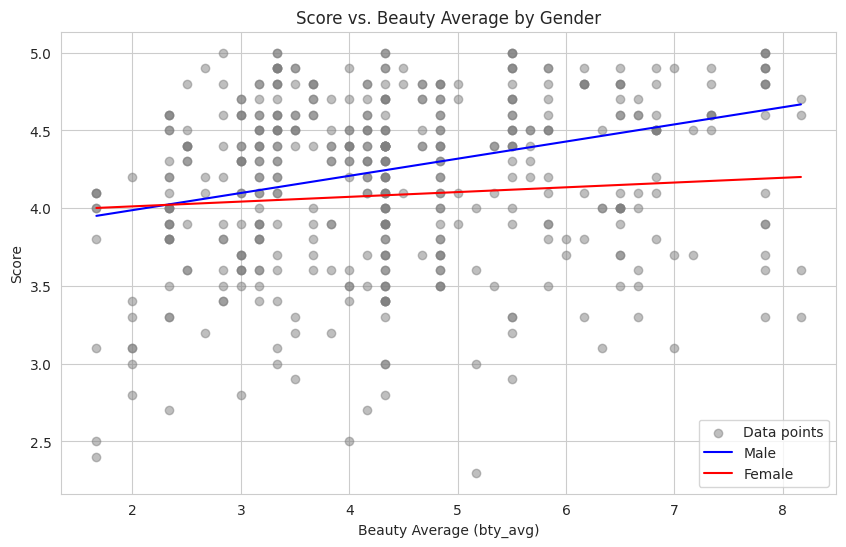

In [9]:
male = courseEval[courseEval['gender_dummy'] == 0]
female = courseEval[courseEval['gender_dummy'] == 1]

model_male = sm.OLS(male['score'], sm.add_constant(male['bty_avg'])).fit()
model_female = sm.OLS(female['score'], sm.add_constant(female['bty_avg'])).fit()

intercept_male, slope_male = model_male.params
intercept_female, slope_female = model_female.params

bty_avg_range = np.linspace(courseEval['bty_avg'].min(), courseEval['bty_avg'].max(), 100)

score_male = intercept_male + slope_male * bty_avg_range
score_female = intercept_female + slope_female * bty_avg_range

plt.figure(figsize=(10, 6))
plt.scatter(courseEval['bty_avg'], courseEval['score'], color='gray', alpha=0.5, label='Data points')

plt.plot(bty_avg_range, score_male, color='blue', label='Male')
plt.plot(bty_avg_range, score_female, color='red', label='Female')

plt.xlabel('Beauty Average (bty_avg)')
plt.ylabel('Score')
plt.title('Score vs. Beauty Average by Gender')
plt.legend()
plt.grid(True)

plt.show()

Yes, since we can see that most of the blue line is higher than the red one, that is, the gender of a male may have higher score than a woman

### <span style="color:red"> Question 4 </span>
P-values and parameter estimates should only be trusted if the conditions for the regression are reasonable. Verify that the conditions for this model are reasonable using diagnostic plots. To check the model conditions you will need to make the following plots (see page 271 of the book for more details about assumptions and example plots):
* scatterplot of the (absolute) residuals (y-axis) against the predicted values (x-axis)
* a histogram and QQ-plot of the residuals
* scatterplot of the residuals (y-axis) against the order of collection (x-axis)
* scatterplots of the residuals (y-axis) against each of the explanatory variables (x-axis)

Make sure you use subplots (plt.subplot) to order these plots in a structured  manner.  

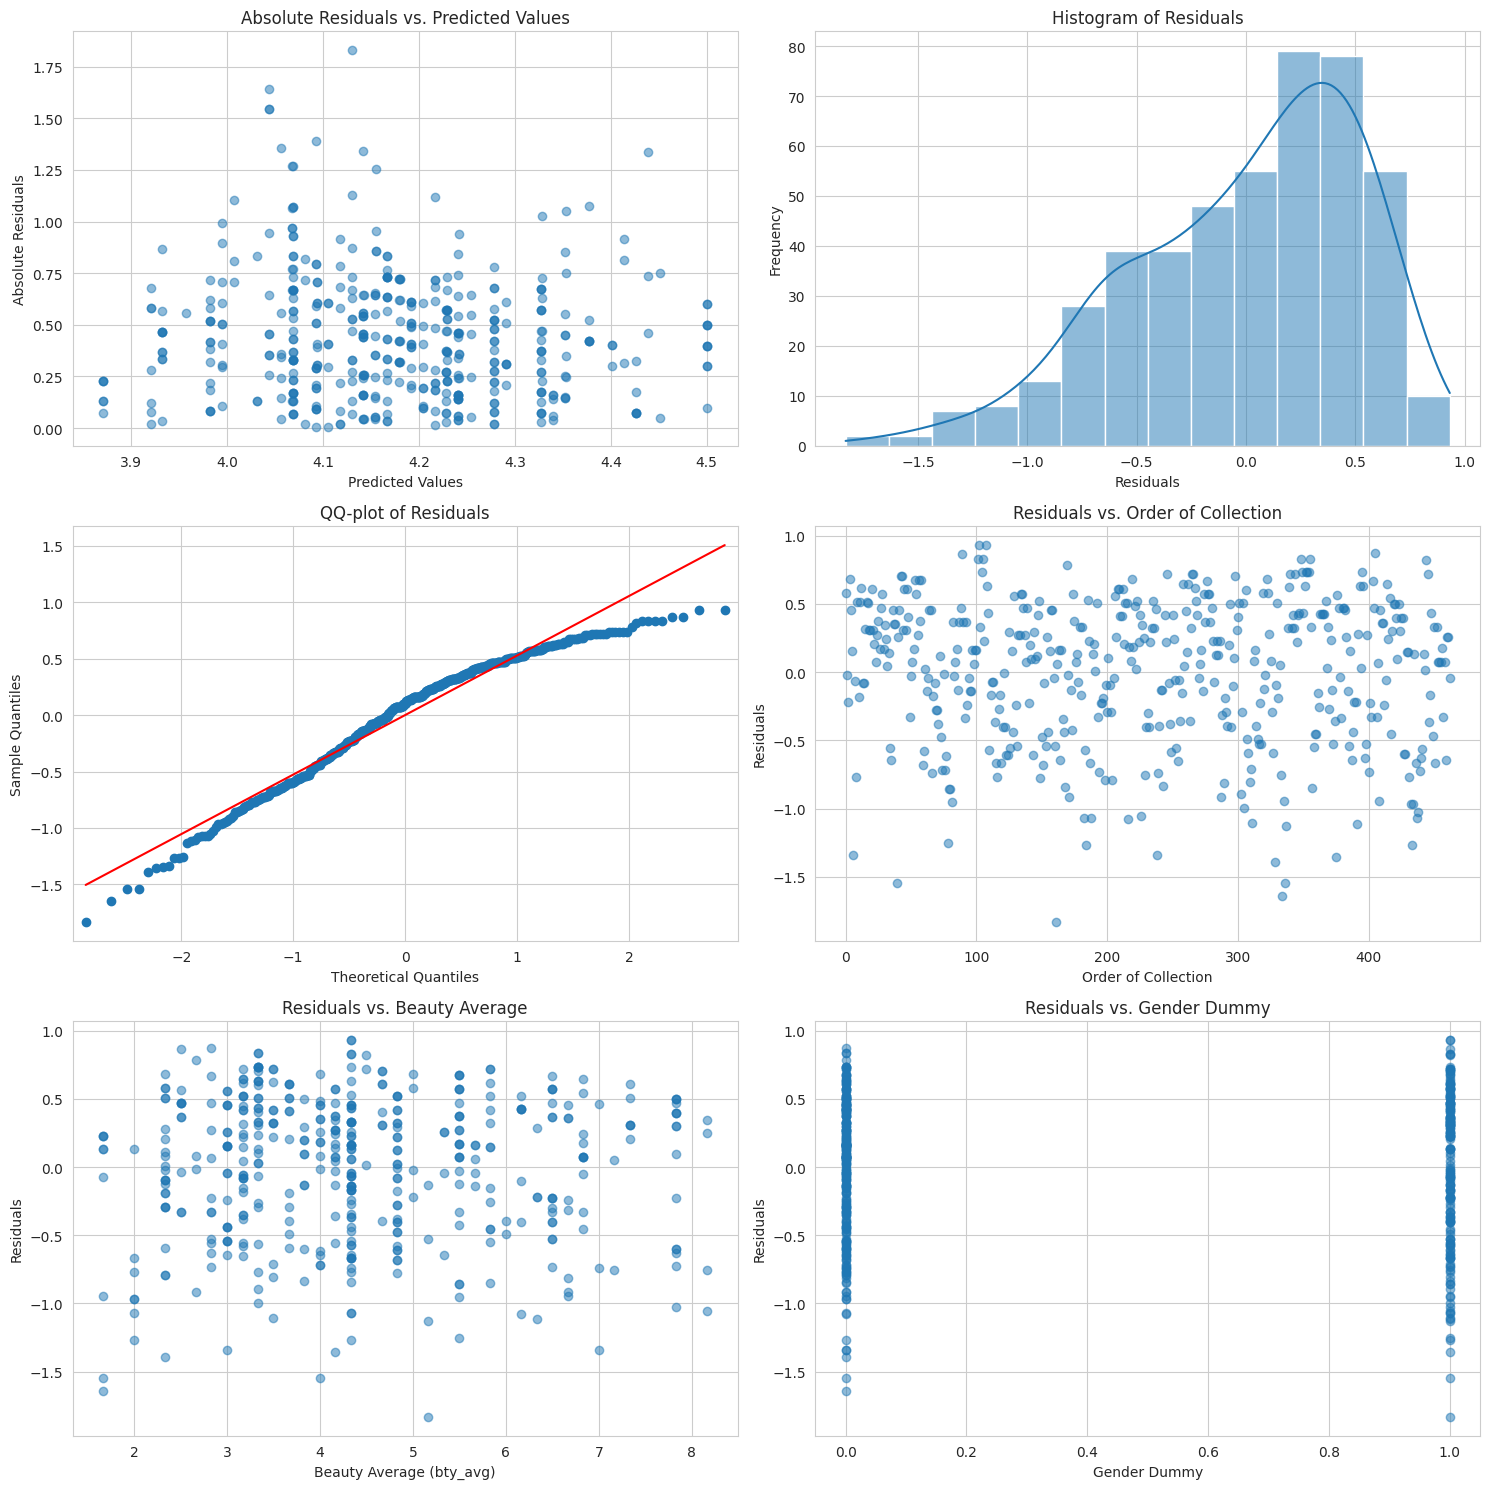

In [10]:
model = sm.formula.ols(formula = 'score ~ bty_avg + gender_dummy', data=courseEval).fit()
residuals = model.resid
predicted = model.fittedvalues

fig, axs = plt.subplots(3, 2, figsize=(15, 15))

axs[0, 0].scatter(predicted, np.abs(residuals), alpha=0.5)
axs[0, 0].set_xlabel('Predicted Values')
axs[0, 0].set_ylabel('Absolute Residuals')
axs[0, 0].set_title('Absolute Residuals vs. Predicted Values')

sns.histplot(residuals, kde=True, ax=axs[0, 1])
axs[0, 1].set_xlabel('Residuals')
axs[0, 1].set_ylabel('Frequency')
axs[0, 1].set_title('Histogram of Residuals')

sm.qqplot(residuals, line='s', ax=axs[1, 0])
axs[1, 0].set_title('QQ-plot of Residuals')

axs[1, 1].scatter(np.arange(len(residuals)), residuals, alpha=0.5)
axs[1, 1].set_xlabel('Order of Collection')
axs[1, 1].set_ylabel('Residuals')
axs[1, 1].set_title('Residuals vs. Order of Collection')

axs[2, 0].scatter(courseEval['bty_avg'], residuals, alpha=0.5)
axs[2, 0].set_xlabel('Beauty Average (bty_avg)')
axs[2, 0].set_ylabel('Residuals')
axs[2, 0].set_title('Residuals vs. Beauty Average')

axs[2, 1].scatter(courseEval['gender_dummy'], residuals, alpha=0.5)
axs[2, 1].set_xlabel('Gender Dummy')
axs[2, 1].set_ylabel('Residuals')
axs[2, 1].set_title('Residuals vs. Gender Dummy')

plt.tight_layout()
plt.show()

1) plot 1\
Mostly constant variability in residuals.

2) plots 2 and 3\
plot 3: Residuals of the model are nearly normal, but the line has the form of a parabola, that is, it is bent in the middle of the graph.\
plot 2: As well, the histogram is right-skewed, that is why it is not fully normal distributed. Does not has a correct bell-shape, is negative-skewed/

3) plot 4\
Residuals are independent, we do not see increasing or decreasing trent there.

4) plots 5 and 6\
plot 5:there are non-linear associations between the explanatory and response variables\
plot 6: Each variable is linearly related to the outcome.

## <span style="color:red"> The search for the best model </span>
We will start with a full model that predicts professor score based on  ethnicity, gender, language of the university where they got their degree (language), age, proportion of students that filled out evaluations (cls_perc_eval), class size (cls_students), course level (cls_level), number of professors (cls_profs), number of credits (cls_credits), average beauty rating (bty_avg), outfit (pic_outfit), and picture color (pic_color).

In [11]:
m_full = sm.formula.ols(formula = 'score ~ ethnicity + gender + language + age + cls_perc_eval + cls_students + cls_level + cls_profs + cls_credits + bty_avg + pic_outfit + pic_color', data = courseEval)
multi_reg = m_full.fit()
print(multi_reg.summary())

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.181
Model:                            OLS   Adj. R-squared:                  0.159
Method:                 Least Squares   F-statistic:                     8.264
Date:                Mon, 03 Jun 2024   Prob (F-statistic):           3.79e-14
Time:                        13:51:37   Log-Likelihood:                -328.37
No. Observations:                 463   AIC:                             682.7
Df Residuals:                     450   BIC:                             736.5
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

### <span style="color:red"> Question 5 </span>
Interpret the coefficient associated with the ethnicity variable.

The coefficient associated with the ethnicity variable indicates the average change in the dependent variable (score) when ethnicity changes from minority to not minority, holding all other variables constant.
In this model, the coefficient for the variable ethnicity is 0.1478. On average, when ethnicity changes from minority to non-minority, and all other variables remain the same, the course score increases by about 0.1478 points.

But the p value associated with this coefficient is 0.058, which exceeds the generally accepted significance level of 0.05. that is, the relationship between ethnicity and course assessment may be statistically insignificant at a confidence level of 95%.

### <span style="color:red"> Question 6 </span>
Drop the variable with the highest p-value and re-fit the model. Did the coefficients and significance of the other explanatory variables change? (One of the things that makes multiple regression interesting is that coefficient estimates depend on the other variables that are included in the model.) If not, what does this say about whether or not the dropped variable was collinear with the other explanatory variables?

In [12]:
m_without_cls_profs= sm.formula.ols(formula = 'score ~ ethnicity + gender + language + age + cls_perc_eval + cls_students + cls_level + cls_credits + bty_avg + pic_outfit + pic_color', data = courseEval)
model_without_cls_profs = m_without_cls_profs.fit()
print(model_without_cls_profs.summary())

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.180
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                     9.026
Date:                Mon, 03 Jun 2024   Prob (F-statistic):           1.26e-14
Time:                        13:51:37   Log-Likelihood:                -328.41
No. Observations:                 463   AIC:                             680.8
Df Residuals:                     451   BIC:                             730.5
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

cls_profs = 0.773 had the highest p value, we excluded this variable. The model has changed, as well as the coefficients and significance of other independent variables

the deleted variable is collinear with other independent variables.

### <span style="color:red"> Question 7 </span>
Using backward-selection and p-value as the selection criterion, determine the best model. You do not need to show all steps in your answer, just the output for the final model.

In [13]:
m_without_cls_profs_level_students_pic_outfit= sm.formula.ols(formula = 'score ~ ethnicity + gender + language + age + cls_perc_eval + cls_credits + bty_avg + pic_color', data = courseEval)
model_without_cls_profs_level_students_pic_outfit = m_without_cls_profs_level_students_pic_outfit.fit()
print(model_without_cls_profs_level_students_pic_outfit.summary())
#now all p-vlaues are smaller than 0.05 and are significant
# removed were cls_profs, cls_level, _cls_students, pic_outfit


                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.158
Method:                 Least Squares   F-statistic:                     11.80
Date:                Mon, 03 Jun 2024   Prob (F-statistic):           2.58e-15
Time:                        13:51:37   Log-Likelihood:                -330.74
No. Observations:                 463   AIC:                             679.5
Df Residuals:                     454   BIC:                             716.7
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

### <span style="color:red"> Question 8 </span>
Verify that the conditions for this model are reasonable using diagnostic plots.
To get the predicted values for a regression model, you can use the *predict* function in your regression model object, so for the example above question 5 that would be: predicted_value = multi_reg.predict(). Make sure you use subplots to order the diagnostic plots in a structured  manner.  

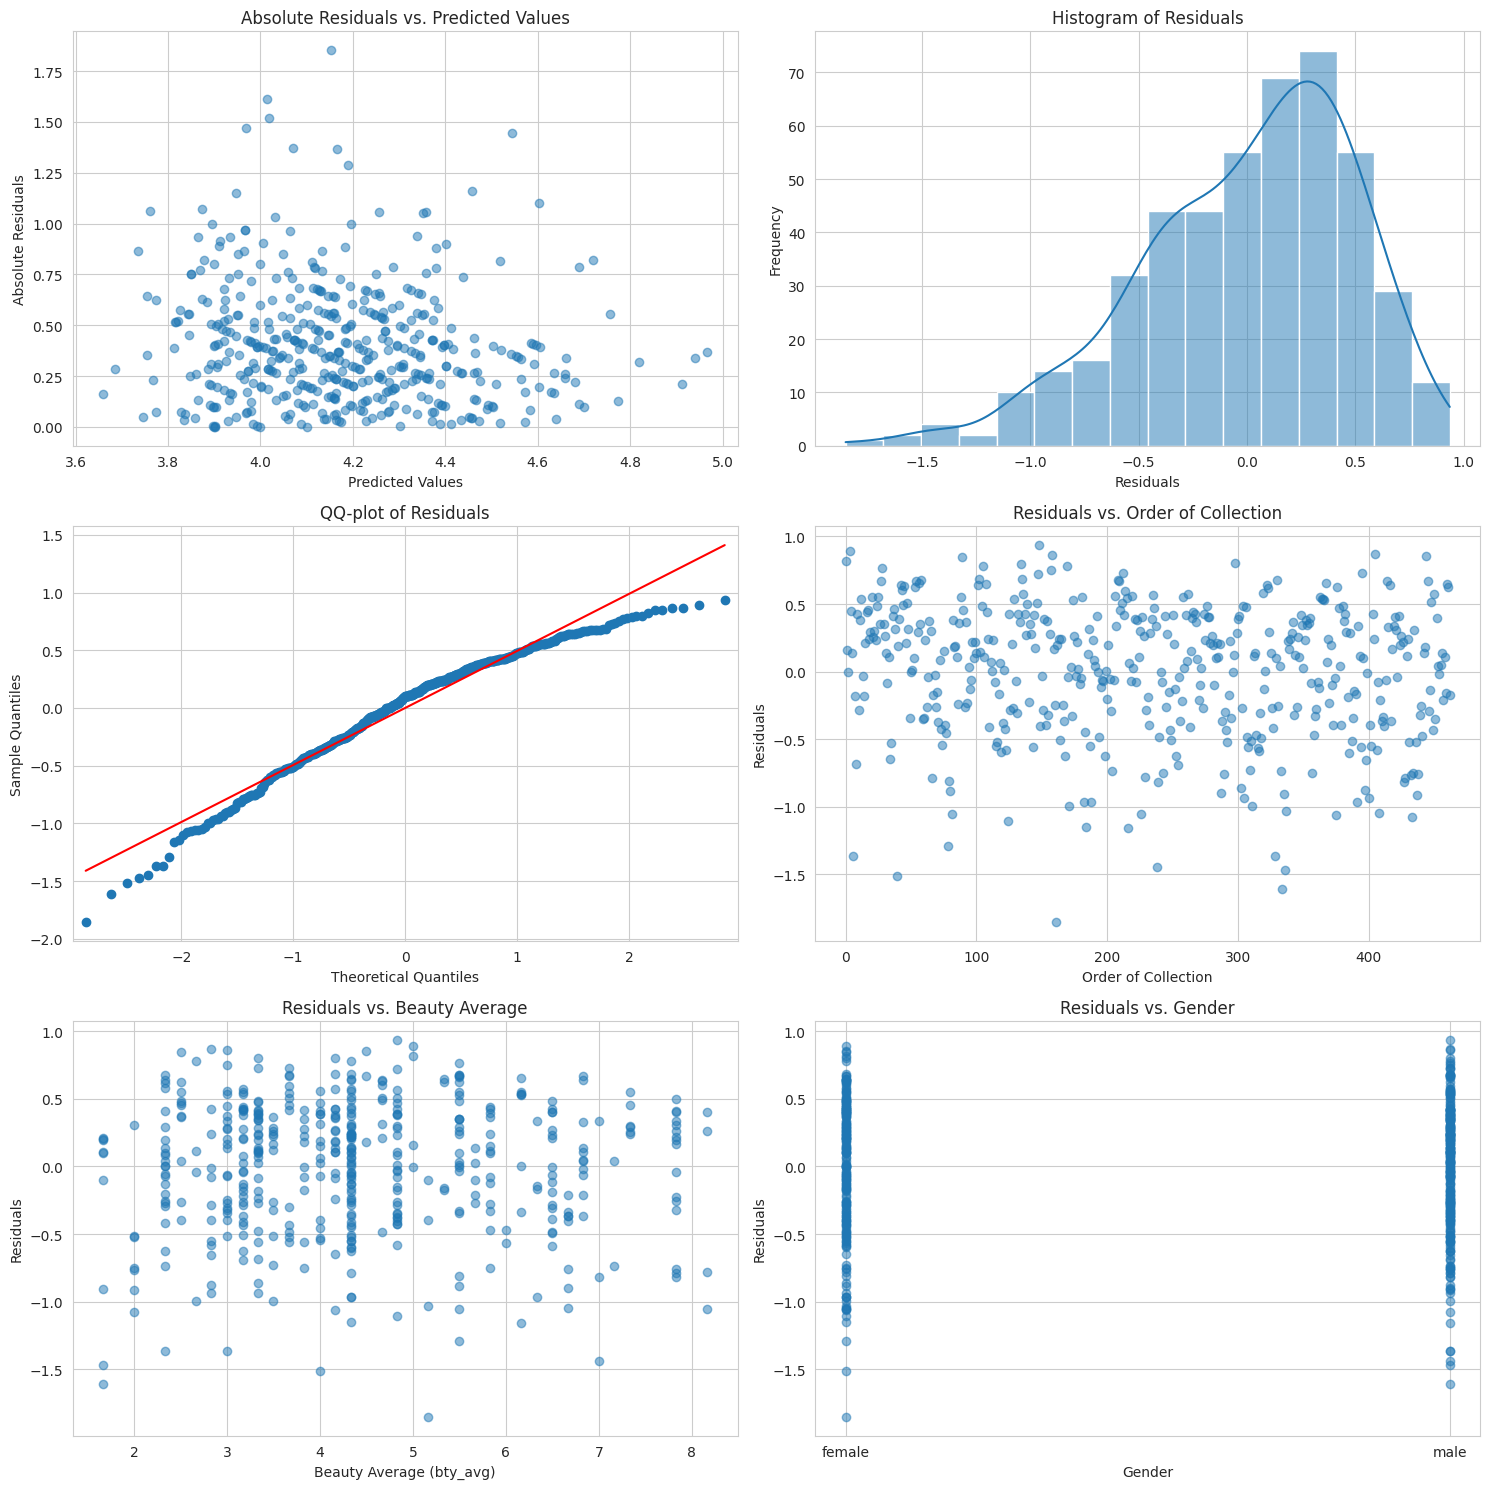

In [14]:
predicted_values = model_without_cls_profs_level_students_pic_outfit.predict()
residuals = model_without_cls_profs_level_students_pic_outfit.resid
abs_residuals = np.abs(residuals)

fig, axs = plt.subplots(3, 2, figsize=(15, 15))

axs[0, 0].scatter(predicted_values, abs_residuals, alpha=0.5)
axs[0, 0].set_xlabel('Predicted Values')
axs[0, 0].set_ylabel('Absolute Residuals')
axs[0, 0].set_title('Absolute Residuals vs. Predicted Values')

sns.histplot(residuals, kde=True, ax=axs[0, 1])
axs[0, 1].set_xlabel('Residuals')
axs[0, 1].set_ylabel('Frequency')
axs[0, 1].set_title('Histogram of Residuals')

sm.qqplot(residuals, line='s', ax=axs[1, 0])
axs[1, 0].set_title('QQ-plot of Residuals')

axs[1, 1].scatter(np.arange(len(residuals)), residuals, alpha=0.5)
axs[1, 1].set_xlabel('Order of Collection')
axs[1, 1].set_ylabel('Residuals')
axs[1, 1].set_title('Residuals vs. Order of Collection')

axs[2, 0].scatter(courseEval['bty_avg'], residuals, alpha=0.5)
axs[2, 0].set_xlabel('Beauty Average (bty_avg)')
axs[2, 0].set_ylabel('Residuals')
axs[2, 0].set_title('Residuals vs. Beauty Average')

axs[2, 1].scatter(courseEval['gender'], residuals, alpha=0.5)
axs[2, 1].set_xlabel('Gender')
axs[2, 1].set_ylabel('Residuals')
axs[2, 1].set_title('Residuals vs. Gender')

plt.tight_layout()
plt.show()



1) plot 1
Mostly constant variability in residuals.

2) plots 2 and 3
plot 3: Residuals of the model are nearly normal, but the line has the form of a parabola, that is, it is bent in the middle of the graph.
plot 2: As well, the histogram is right-skewed, that is why it is not fully normal distributed. Does not has a correct bell-shape, is negative-skewed/

3) plot 4
Residuals are independent, we do not see increasing or decreasing trent there.

4) plots 5 and 6
plot 5:there are non-linear associations between the explanatory and response variables
plot 6: Each variable is linearly related to the outcome.


### <span style="color:red"> Question 9 </span>
The original paper describes how these data were gathered by taking a sample of professors from the University of Texas at Austin and including all courses that they have taught. Considering that each row represents a course, could this new information have an impact on any of the conditions of linear regression?

Yes, this can affect linear regression, since\
1) one teacher can teach more than one course, which means that the independence of observations may be violated. Since one teacher can teach several subjects, the assessment may be similar for the courses of this teacher, and that is, there may be a correlation of the residuals\
2) Students can also rate the course higher because they like a certain teacher or vice versa. In this case, certain courses taught by one teacher may have a better or worse grade due to the fact that there was 1 teacher.

### <span style="color:red"> Question 10 </span>
Based on your final model, describe the characteristics of a professor and course at University of Texas at Austin that would be associated with a high evaluation score. Would you be comfortable generalizing your conclusions to apply to professors generally (at any university)? Why or why not?

The characteristics of a professor and course at the University of Texas at Austin that would be associated with a high evaluation score:
Ethnicity - identification as "not minority"\
Gender - male professors \
Language - teaching in English\
Picture Color - courses where the professor's picture is in color\
Age - young\
Class Credits - courses with one credit\
Class Percentage Evaluation - a higher percentage of students evaluating the class\
Beauty Average - professors with higher beauty ratings \


We would not be comfortable generalizing these conclusions to apply to professors at any university. It because of specific data to the University of Texas at Austin that can differ in other Unis or places due to differences in student populations, cultural context, environments.
Different Universities can have different courses and evaluation systems, structures.